Day 1 excel_connect

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from google.colab import auth
import gspread
from google.auth import default
import pandas as pd
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
worksheet = gc.open('DL').sheet1
rows = worksheet.get_all_values()
df = pd.DataFrame(rows[1:], columns=rows[0])

In [ ]:
df=df.astype({'Input':'float'})
df=df.astype({'Output':'float'})
df.head()
x=df[['Input']].values
y=df[['Output']].values

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.33,random_state = 33)
Scaler = MinMaxScaler()
Scaler.fit(X_train)
X_train1 = Scaler.transform(X_train)

In [ ]:
ai_brain=Sequential([
    Dense(units=7,input_shape=[1]),
    Dense(units=5,activation='relu'),
    Dense(units=3,activation='relu'),
    Dense(units=1)
])
ai_brain.compile(optimizer = 'rmsprop', loss = 'mse')
ai_brain.fit(X_train1,y_train,epochs = 2500)

Epoch 1/2500


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step - loss: 1570.9830
Epoch 2/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1569.9230
Epoch 3/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1569.2441
Epoch 4/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1568.7885
Epoch 5/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1568.4408
Epoch 6/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1568.1912
Epoch 7/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1567.9673
Epoch 8/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1567.7500
Epoch 9/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1567.5366
Epoch 10/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1567.3251
Epoch 11/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1567.1154
Epoch 12/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1566.9058
Epoch 13/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1566.6965
Epoch 14/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1566.4865
Epoch 15/2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

<Axes: >

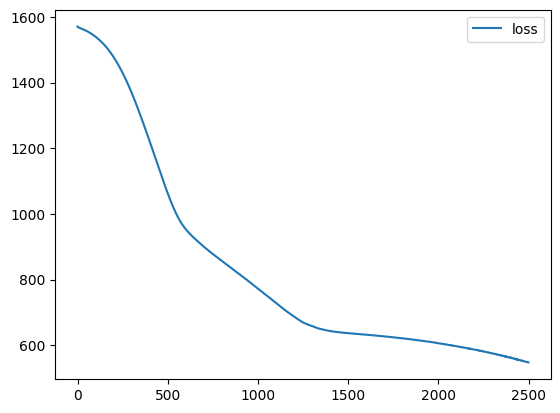

In [ ]:
loss_df = pd.DataFrame(ai_brain.history.history)
loss_df.plot()

In [ ]:
X_test1 = Scaler.transform(X_test)
ai_brain.evaluate(X_test1,y_test)
X_n1 = [[57]]
X_n1_1 = Scaler.transform(X_n1)
ai_brain.predict(X_n1_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - loss: 761.8533
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


array([[1.6952509]], dtype=float32)

**Exp 2**

In [ ]:
import numpy as np
import tensorflow as tf

In [ ]:
# Provide path to get the full path
data_path = pd.read_csv("mnist.npz")

# Load data (discard test set)
(training_images, training_labels), _ = tf.keras.datasets.mnist.load_data(path=data_path)

print(f"training_images is of type {type(training_images)}.\ntraining_labels is of type {type(training_labels)}\n")

# Inspect shape of the data
data_shape = training_images.shape

print(f"There are {data_shape[0]} examples with shape ({data_shape[1]}, {data_shape[2]})")

NameError: name 'pd' is not defined